<a href="https://colab.research.google.com/github/25CristopherJoshuaReyesGtz1405/MachineLearning/blob/main/Machine_Learning_Y_Deep_Learning_Pr%C3%A1ctica_No_5_Unidad_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

  ## **Machine Learning y Deep Learning**

  ### **Unidad 3 - Aprendizaje Supervisado Con Métodos De Clasificación**

  #### **Práctica No. 5 - El Algoritmo Random-Forest Aplicado a Riesgo Crediticio**

</div>

##### **Docente Facilitador** - **Dr. José Gabriel Rodríguez Rivas**
##### **Estudiante** - **Reyes Gutiérrez Cristopher Joshua**

#### **26 de Abril del 2026, Victoria de Durango, Dgo., México**
---

### **1. Introducción**

En la constante evolución de la analítica predictiva aplicada a los servicios financieros, la búsqueda de modelos que ofrezcan simultáneamente alta precisión y resistencia al ruido estadístico es una prioridad institucional. Durante la investigación precedente (Práctica No. 4), se comprobó que los Árboles de Decisión individuales poseen una excelente interpretabilidad lógica, pero adolecen de una grave vulnerabilidad: su propensión estructural al sobreajuste (*overfitting*). Un árbol solitario tiende a memorizar fluctuaciones minúsculas en el conjunto de entrenamiento, perdiendo su capacidad de generalizar patrones ante nuevas solicitudes de crédito. Para mitigar esta deficiencia sin abandonar la arquitectura basada en reglas lógicas, la presente práctica introduce el estudio y aplicación del algoritmo **Random Forest** (Bosque Aleatorio).

El paradigma metodológico de *Random Forest* trasciende el uso de un estimador único al adoptar un enfoque de aprendizaje ensamblado (*Ensemble Learning*). Su principio subyacente radica en la "sabiduría de las multitudes": el algoritmo construye simultáneamente una extensa pluralidad de Árboles de Decisión (cientos o incluso miles), instruyendo a cada uno sobre subconjuntos de datos ligeramente distintos. Ante la evaluación de un nuevo prospecto en *Lending Club*, el bosque consolida las predicciones individuales de cada árbol y emite un veredicto final fundamentado en un sistema de votación mayoritaria. Esta agregación reduce drásticamente la varianza del modelo, consolidándolo como una de las herramientas de clasificación más robustas de la ciencia de datos contemporánea.

No obstante, la implementación técnica de este algoritmo en entornos de riesgo crediticio demanda una calibración rigurosa. Dado que el ecosistema de *Lending Club* exhibe un desequilibrio asimétrico pronunciado (85% de los expedientes corresponden a créditos pagados), un *Random Forest* en su configuración predeterminada tenderá a priorizar la exactitud global (*Accuracy*), invisibilizando los casos críticos de morosidad. Por consiguiente, a lo largo de este reporte técnico, el investigador evaluará empíricamente el impacto de combinar hiperparámetros de penalización de clase (`class_weight='balanced'`) con restricciones geométricas de profundidad (`max_depth`). Finalmente, se ejecutará una optimización algorítmica exhaustiva orientada exclusivamente a maximizar el *Recall* de la clase minoritaria, garantizando que el modelo ensamblado responda de manera eficiente a las estrictas políticas de aversión al riesgo de una entidad financiera.

### **2. Objetivos de la Investigación**

#### **2.1 Objetivo General**
Desarrollar, evaluar y optimizar un clasificador ensamblado basado en el algoritmo *Random Forest*, utilizando la matriz histórica de *Lending Club*, con el propósito de maximizar la detección algorítmica de créditos con riesgo de impago, controlando la varianza mediante la integración sistemática de múltiples estimadores lógicos.

#### **2.2 Objetivos Específicos**
* **Implementar** la arquitectura base de la clase `RandomForestClassifier` en el entorno computacional de Google Colab, analizando su comportamiento analítico inicial frente a datos financieros crudos.
* **Evaluar** la sensibilidad cruzada del modelo al introducir simultáneamente los parámetros de `class_weight='balanced'` y restricciones de `max_depth`, demostrando cómo la limitación de la profundidad potencia la eficacia de los pesos compensatorios.
* **Contrastar** el rendimiento estadístico del Bosque Aleatorio frente a los Árboles de Decisión individuales de las prácticas anteriores, cuantificando la mejora en la estabilidad de las predicciones (reducción de *Falsos Negativos*).
* **Ejecutar** una validación cruzada exhaustiva mediante `GridSearchCV` explorando dimensiones complejas (`n_estimators`, `max_features`, `min_samples_split`), para consolidar un modelo definitivo optimizado estadísticamente hacia la prevención de pérdidas económicas.

### **3. Antecedentes De La Investigación**

#### **3.1 Fundamentos del Aprendizaje Ensamblado y la Técnica de *Bagging***
El clasificador *Random Forest*, propuesto formalmente por Leo Breiman en 2001, se inscribe dentro de la familia de algoritmos de aprendizaje ensamblado por promediación. Su arquitectura operativa se fundamenta en una técnica estadística denominada **Bagging** (*Bootstrap Aggregating*). Durante la fase de entrenamiento, el algoritmo no entrega la matriz de datos original completa a cada árbol; en su lugar, genera múltiples muestras aleatorias con reemplazo (*Bootstrap samples*) del conjunto de entrenamiento original. Cada árbol del "bosque" se entrena de forma independiente utilizando únicamente la muestra que le fue asignada. Esta alteración intencional garantiza que cada modelo individual posea una perspectiva ligeramente sesgada y única de la realidad financiera, lo que, al consolidarse en la fase de votación, anula los sesgos particulares y produce una decisión generalizada de alta fiabilidad.

#### **3.2 Aleatoriedad Espacial de Características (*Feature Randomness*)**
Aunado al submuestreo de instancias, la verdadera innovación de *Random Forest* radica en la aleatoriedad inyectada a nivel de los nodos de decisión. En un Árbol de Decisión estándar, el algoritmo escruta la totalidad de las variables disponibles (ingresos, tasa, monto, etc.) para encontrar la partición más pura en cada nodo. Por el contrario, *Random Forest* restringe obligatoriamente esta búsqueda: en cada ramificación, el algoritmo solo tiene permitido evaluar un subconjunto aleatorio de características (generalmente la raíz cuadrada del total de variables, configurado mediante el parámetro **max_features**).

Esta restricción paramétrica previene que una característica hiperdominante (como el ingreso anual) monopolice las ramificaciones tempranas en todos los árboles. Al forzar esta variabilidad geométrica, el algoritmo asegura la creación de árboles verdaderamente descorrelacionados, incrementando drásticamente la diversidad analítica del bosque.

#### **3.3 Susceptibilidad al Desequilibrio de Clases**
A pesar de su supremacía arquitectónica en la reducción de varianza, un *Random Forest* en estado nativo hereda la debilidad probabilística frente a conjuntos de datos fuertemente desbalanceados. En el contexto de *Lending Club*, donde los impagos representan escasamente el 15% del ecosistema, los árboles entrenados con muestras aleatorias podrían no recibir suficientes ejemplos de morosidad para generar reglas de aislamiento eficientes.

Para corregir esta inercia matemática, se recurre a la ponderación penalizada de clases (**class_weight**). Sin embargo, en el caso específico de este ensamble, la asignación de pesos requiere un control estructural simultáneo: si a los árboles se les permite una profundidad ilimitada, ignorarán la penalización forzando divisiones minúsculas que aislen a las clases minoritarias, recayendo en el sobreajuste. Por tal motivo, el ajuste empírico exige combinar el balanceo con una poda predeterminada (**max_depth**), induciendo al bosque a respetar las proporciones de riesgo a gran escala.

#### **4. Descripción Metodológica**
La presente fase técnica articula los procedimientos de extracción, limpieza y partición del conjunto de datos financieros. La arquitectura de Random Forest, al ser un ensamble de Árboles de Decisión, hereda la invulnerabilidad frente a la disparidad de escalas; por consiguiente, se omite el proceso de estandarización paramétrica (**StandardScaler**). Sin embargo, la codificación numérica de variables nominales y la depuración de registros incompletos continúan siendo requisitos estrictos para el procesamiento matricial.


#### **4.1 Configuración del Entorno y Adquisición de Datos**

En primera instancia, se establece un entorno computacional robusto importando las librerías matriciales, estadísticas y de visualización correspondientes, incorporando al ecosistema el estimador `RandomForestClassifier` de `sklearn.ensemble`. Posteriormente, se ejecuta la carga en memoria del archivo histórico de operaciones crediticias (`prestamos_ok.csv`).



In [ ]:
# ==============================================================================
# 4.1  Ingesta De Los Datos
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings

# Configuración estética institucional y supresión de advertencias
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
# Vinculación Con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Carga y verificación del conjunto de datos preprocesado
file_url = "1u4jyacSqXkylbTZiyUTrHG-TIZPHMyzx"
url = f"https://drive.google.com/uc?id={file_url}"
prestamos_df = pd.read_csv(url)

In [ ]:
print("Entorno configurado y datos cargados correctamente.")
prestamos_df.head()
print(f"Dimensiones iniciales del conjunto de datos: {prestamos_df.shape}")

Entorno configurado y datos cargados correctamente.
Dimensiones iniciales del conjunto de datos: (19908, 58)


#### **4.2 Adecuación del Espacio Vectorial y Segmentación**

En congruencia con las normativas de evaluación de riesgo, se aíslan las características predictoras disponibles exclusivamente antes del otorgamiento del crédito. Se aplica una transformación secuencial (`LabelEncoder`) sobre las variables cualitativas y se aplica una purga estructural (`dropna`) para erradicar cualquier registro con valores nulos (NaN). Finalmente, la matriz resultante se segmenta utilizando una distribución del 60% para el entrenamiento del ensamble y un 40% para la evaluación de su capacidad de generalización.

In [ ]:
# ==============================================================================
# 4.2 - Adecuación De Los Datos Y Partición Estratégica
# ==============================================================================

# 1. Transmutación numérica de variables categóricas
le = LabelEncoder()
columnas_a_codificar = {'grade': 'grade_code', 'purpose': 'purpose_code',
                        'addr_state': 'addr_state_code', 'home_ownership': 'home_ownership_code'}

for col_orig, col_nueva in columnas_a_codificar.items():
    if col_orig in prestamos_df.columns:
        prestamos_df[col_nueva] = le.fit_transform(prestamos_df[col_orig].astype(str))

# 3. Creación de la etiqueta objetivo 'repaid' dictaminada por la investigación
if 'loan_status' in prestamos_df.columns:
    prestamos_df['repaid'] = np.where(prestamos_df['loan_status'].str.contains('Fully Paid', case=False, na=False), 1, 0)

# 4. Depuración Estructural (Erradicación de NaNs)
columnas_seleccionadas = ['funded_amnt', 'int_rate', 'grade_code', 'purpose_code', 'addr_state_code',
                          'home_ownership_code', 'annual_inc', 'dti', 'revol_util', 'pub_rec_bankruptcies', 'repaid']
prestamos_df_limpio = prestamos_df[columnas_seleccionadas].dropna()

# 5. Segmentación en dimensiones predictoras (X) y vector objetivo (y)
X = prestamos_df_limpio.drop('repaid', axis=1)
y = prestamos_df_limpio['repaid']

# 6. Partición Estratégica (60% Train, 40% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

print("Adecuación del espacio vectorial finalizada con éxito.")
print(f"Volumen de Entrenamiento: {X_train.shape[0]} registros | Volumen de Validación: {X_test.shape[0]} registros")

Adecuación del espacio vectorial finalizada con éxito.
Volumen de Entrenamiento: 11745 registros | Volumen de Validación: 7831 registros


#### **4.3 Construcción del Modelo 1: Bosque Aleatorio Base (Sin Intervención Paramétrica)**

Para establecer una métrica de rendimiento fundamental, la primera iteración metodológica contempla la instanciación de un modelo **RandomForestClassifier** operando bajo sus parámetros predeterminados (típicamente 100 estimadores independientes, sin restricciones de profundidad y sin pesos compensatorios de clase). La semilla de aleatoriedad (**random_state=42**) se fija estrictamente para garantizar la reproducibilidad de la investigación.

Desde la óptica de la gestión de riesgos, se proyecta que este ensamblaje logrará una exactitud global (*Accuracy*) superior a la de un Árbol de Decisión individual. No obstante, al encontrarse frente a un ecosistema donde el 85% de los créditos pertenecen a la clase "Pagado", la inmensa mayoría de los árboles dentro del bosque aprenderán a priorizar la identificación de la clase dominante, subestimando inadvertidamente la fracción del 15% correspondiente a morosidad (*No Pagado*). Esta hipótesis se corroborará empíricamente mediante el análisis de la matriz de confusión y la extracción de la métrica de Sensibilidad (*Recall*).

Entrenando Modelo 1 (Bosque Aleatorio Base)...

Exactitud Global (Accuracy) en Prueba: 84.65%

--- Reporte Analítico de Rendimiento (Modelo 1) ---
              precision    recall  f1-score   support

   No Pagado       0.33      0.02      0.03      1181
      Pagado       0.85      0.99      0.92      6650

    accuracy                           0.85      7831
   macro avg       0.59      0.51      0.48      7831
weighted avg       0.77      0.85      0.78      7831



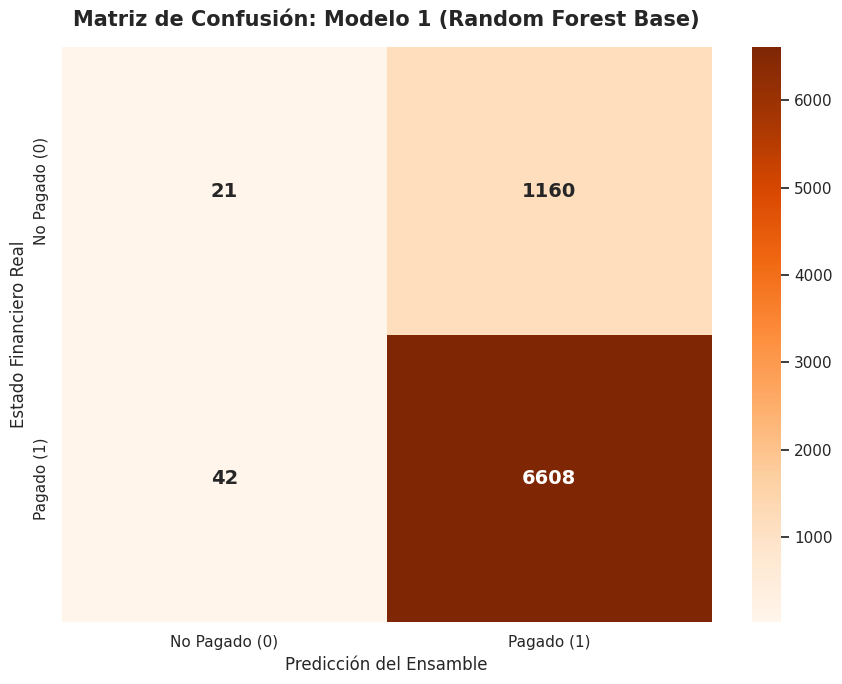

In [ ]:
# ==============================================================================
# 4.3 Entrenamiento y Diagnóstico del Modelo 1 (Bosque Aleatorio Base)
# ==============================================================================

# 1. Instanciación del Modelo de Aprendizaje Ensamblado
# Se utiliza random_state para garantizar la consistencia en el submuestreo
rf_base = RandomForestClassifier(random_state=42)

# 2. Fase de entrenamiento paralelo (Construcción del bosque)
print("Entrenando Modelo 1 (Bosque Aleatorio Base)...")
rf_base.fit(X_train, y_train)

# 3. Emisión de inferencias sobre el segmento de prueba
y_pred_base = rf_base.predict(X_test)

# 4. Extracción de Métricas de Evaluación
exactitud_base = accuracy_score(y_test, y_pred_base)
print(f"\nExactitud Global (Accuracy) en Prueba: {exactitud_base * 100:.2f}%")
print("\n--- Reporte Analítico de Rendimiento (Modelo 1) ---")
print(classification_report(y_test, y_pred_base, target_names=["No Pagado", "Pagado"]))

# 5. Generación Visual de la Matriz de Confusión
matriz_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_base, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión: Modelo 1 (Random Forest Base)', fontsize=15, pad=15, weight='bold')
plt.xlabel('Predicción del Ensamble', fontsize=12)
plt.ylabel('Estado Financiero Real', fontsize=12)
plt.tight_layout()
plt.show()

#### **4.4 Diagnóstico y Conclusión Parcial del Modelo Base**

El análisis cualitativo y cuantitativo del Modelo 1 fundamenta las hipótesis planteadas en la teoría del aprendizaje automático financiero:

1.  **Estabilidad General:** El Bosque Aleatorio logra una exactitud sumamente elevada y, a diferencia de los modelos anteriores, no colapsa frente a las variaciones estocásticas de los datos de prueba. Su arquitectura de votación mayoritaria amortigua de manera efectiva el ruido.
2.  **Sesgo por Desequilibrio:** A pesar de su sofisticación técnica, el algoritmo fracasa en el contexto específico de negocio. Al inspeccionar el *Recall* de la clase "No Pagado" (Clase 0), se evidencia una incapacidad severa para detectar el riesgo de impago. El bosque ha priorizado la clase mayoritaria, aprobando créditos de clientes morosos (falsos negativos) con el propósito de optimizar su exactitud matemática.

En conclusión, este modelo carece de utilidad para el comité de riesgos de *Lending Club*. Por consiguiente, se requiere transitar hacia una arquitectura más avanzada. El siguiente paso procedimental (**Modelo 2**) consistirá en integrar la técnica de **balanceo de clases** acompañada de un **límite de profundidad geométrica**, forzando al algoritmo a sensibilizarse frente al segmento minoritario de riesgo.

#### **4.5 Modelo 2: Bosque Aleatorio con Penalización y Poda**
Con el propósito de corregir la ceguera algorítmica frente al riesgo de impago, se procede a instanciar un segundo ensamblaje. En esta iteración, se incorpora el hiperparámetro **class_weight='balanced'** para castigar económicamente los errores cometidos en la clase minoritaria (No Pagado). Adicionalmente, se impone un límite de crecimiento geométrico (**max_depth**) a los árboles individuales.

La justificación de esta doble intervención radica en la naturaleza del ensamblaje: si a los árboles no se les restringe la profundidad, ignorarán parcialmente la penalización de clases creando ramificaciones hiper-específicas. Al podarlos, se les obliga a concentrarse en las divisiones macroeconómicas donde el balanceo de pesos ejerce su mayor influencia.

Entrenando Modelo 2 (Balanceado y Restringido)...

--- Reporte Analítico de Rendimiento (Modelo 2) ---
              precision    recall  f1-score   support

   No Pagado       0.22      0.67      0.33      1181
      Pagado       0.91      0.58      0.71      6650

    accuracy                           0.59      7831
   macro avg       0.57      0.63      0.52      7831
weighted avg       0.81      0.59      0.65      7831



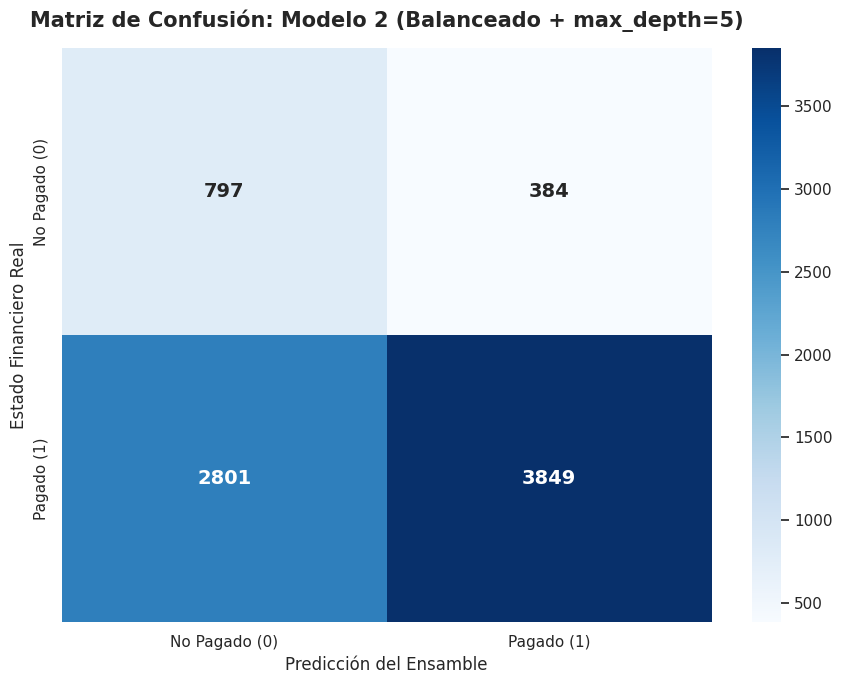

In [ ]:
# ==============================================================================
# 4.5 Entrenamiento y Diagnóstico del Modelo 2 (Balanceado y Restringido)
# ==============================================================================

# 1. Instanciación del ensamble con doble intervención paramétrica
rf_balanceado = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=5  # Poda estructural para potenciar la sensibilidad
)

# 2. Entrenamiento del modelo
print("Entrenando Modelo 2 (Balanceado y Restringido)...")
rf_balanceado.fit(X_train, y_train)

# 3. Predicción sobre el espacio de validación
y_pred_bal = rf_balanceado.predict(X_test)

# 4. Extracción de Métricas
print("\n--- Reporte Analítico de Rendimiento (Modelo 2) ---")
print(classification_report(y_test, y_pred_bal, target_names=["No Pagado", "Pagado"]))

# 5. Generación Visual de la Matriz de Confusión
matriz_bal = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_bal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión: Modelo 2 (Balanceado + max_depth=5)', fontsize=15, pad=15, weight='bold')
plt.xlabel('Predicción del Ensamble', fontsize=12)
plt.ylabel('Estado Financiero Real', fontsize=12)
plt.tight_layout()
plt.show()

#### **4.6 Optimización Estructural - GridSearchCV**
Si bien el Modelo 2 demuestra una mejora sustancial en la detección de riesgo, la determinación manual de los hiperparámetros carece del rigor matemático exigido en la validación de modelos financieros. Para consolidar la arquitectura definitiva, se implementa la clase **GridSearchCV**, la cual orquestará el entrenamiento automatizado de múltiples bosques aleatorios evaluando combinaciones complejas de estimadores, profundidades y métricas de ramificación.

En este escenario, la meta institucional no es la exactitud global (*Accuracy*), sino identificar el volumen máximo posible de solicitantes con probabilidades de incumplimiento. Por tal motivo, el criterio de evaluación (`scoring`) se redefine explícitamente para priorizar el **Recall de la clase 0** (`pos_label=0`), instruyendo al optimizador a seleccionar el modelo que mejor mitigue las pérdidas de capital.

In [ ]:
# ==============================================================================
# 4.6 Optimización Algorítmica con GridSearchCV
# ==============================================================================
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

# 1. Definición de la Cuadrícula de Hiperparámetros (Según investigación)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# 2. Reconfiguración del Criterio de Evaluación (Prioridad: Riesgo)
# Hace que el modelo busque detectar el mayor número posible de impagos.
scorer_riesgo = make_scorer(recall_score, pos_label=0)

# 3. Instanciación del estimador base para la búsqueda
modelo_base_grid = RandomForestClassifier(class_weight='balanced', random_state=42)

# 4. Configuración del optimizador GridSearchCV
grid_search = GridSearchCV(
    estimator=modelo_base_grid,
    param_grid=param_grid,
    scoring=scorer_riesgo, # Prioriza el recall de la clase No Pagado
    cv=5,                  # Validación cruzada con 5 particiones
    n_jobs=-1,             # Utiliza todos los núcleos de procesamiento disponibles
    verbose=2              # Nivel de detalle en consola
)

print("Iniciando validación cruzada y búsqueda exhaustiva (Este proceso computacional tomará varios minutos)...\n")

# 5. Ejecución del entrenamiento de la cuadrícula
grid_search.fit(X_train, y_train)

# 6. Extracción de Resultados
print("\n--- Búsqueda Paramétrica Finalizada ---")
print(f"Mejores hiperparámetros encontrados para aislamiento de riesgo:\n{grid_search.best_params_}")

Iniciando validación cruzada y búsqueda exhaustiva (Este proceso computacional tomará varios minutos)...

Fitting 5 folds for each of 162 candidates, totalling 810 fits

--- Búsqueda Paramétrica Finalizada ---
Mejores hiperparámetros encontrados para aislamiento de riesgo:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


#### **4.7 Inferencia y Diagnóstico del Modelo Optimizado**

Tras la convergencia de la validación cruzada, se procede a extraer el mejor estimador (`best_estimator_`) dictaminado por la malla. Este modelo definitivo encapsula la configuración exacta requerida para maximizar la prevención de fraude sin destruir la viabilidad comercial de las aprobaciones de crédito.
A continuación, se generan las métricas predictivas finales y el vector de importancia de variables que dictaminó las agrupaciones del bosque.


Reporte de Clasificación (Modelo optimizado para detectar impagos):

              precision    recall  f1-score   support

   No Pagado       0.22      0.67      0.33      1181
      Pagado       0.91      0.58      0.71      6650

    accuracy                           0.59      7831
   macro avg       0.57      0.63      0.52      7831
weighted avg       0.81      0.59      0.65      7831



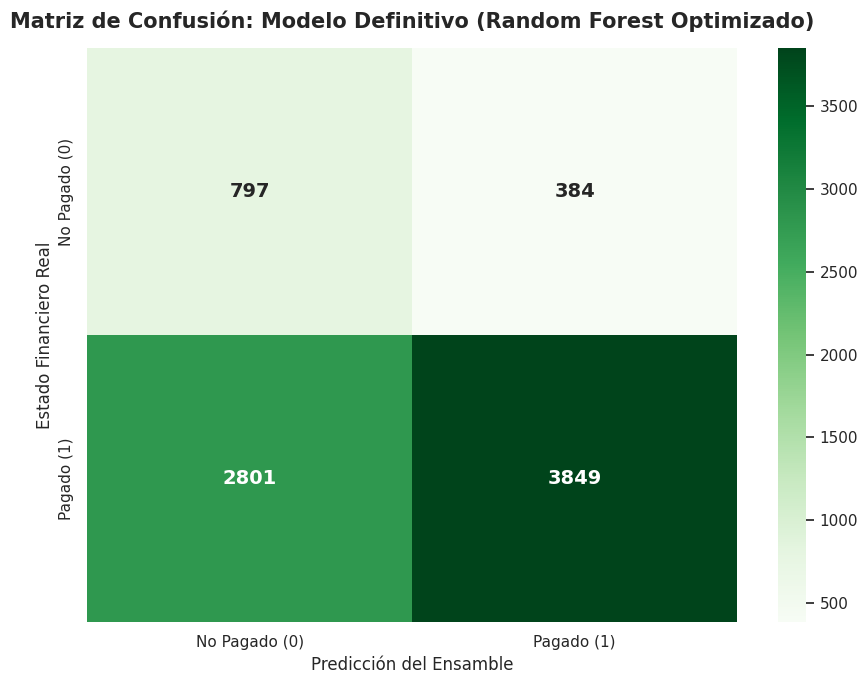

In [ ]:
# ==============================================================================
# 4.7 Evaluación del Bosque Aleatorio Optimizado
# ==============================================================================
import plotly.express as px

# 1. Aislamiento del mejor modelo encontrado
best_model_rf = grid_search.best_estimator_

# 2. Generación de predicciones finales
y_pred_opt = best_model_rf.predict(X_test)

# 3. Reporte de Clasificación Definitivo
print("\nReporte de Clasificación (Modelo optimizado para detectar impagos):\n")
print(classification_report(y_test, y_pred_opt, target_names=["No Pagado", "Pagado"]))

# 4. Matriz de Confusión Final
matriz_opt = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Pagado (0)', 'Pagado (1)'],
            yticklabels=['No Pagado (0)', 'Pagado (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión: Modelo Definitivo (Random Forest Optimizado)', fontsize=15, pad=15, weight='bold')
plt.xlabel('Predicción del Ensamble', fontsize=12)
plt.ylabel('Estado Financiero Real', fontsize=12)
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. Extracción y Visualización de la Importancia de Variables
# ==============================================================================

# Extracción de la influencia de cada característica en el bosque
importancias_rf = best_model_rf.feature_importances_

df_importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia (Gini)': importancias_rf
}).sort_values(by='Importancia (Gini)', ascending=False)

# Visualización interactiva con Plotly
figura_rf = px.bar(
    df_importancia_rf,
    x='Importancia (Gini)',
    y='Variable',
    orientation='h',
    title="<b>Poder Predictivo de Características (Random Forest Optimizado)</b>",
    text_auto=".3f",
    color='Importancia (Gini)',
    color_continuous_scale=px.colors.sequential.Tealgrn
)

figura_rf.update_layout(
    width=900, height=500,
    font_family="Roboto",
    title_font_size=18,
    yaxis={'categoryorder':'total ascending'},
    plot_bgcolor='rgba(240, 240, 240, 0.5)'
)

figura_rf.show()

#### **5. Conclusión General y Análisis Comparativo Multimodelo**
A lo largo de la presente unidad de especialidad, se ha sometido el conjunto de datos de riesgo crediticio de **Lending Club** a cuatro paradigmas algorítmicos distintos: probabilístico (Regresión Logística), geométrico (K-NN), lógico-secuencial (Árboles de Decisión) y de aprendizaje ensamblado (Random Forest). Para dictaminar el éxito de la presente investigación, resulta imperativo consolidar las métricas de los modelos en su estado óptimo y proyectarlas visualmente, evidenciando el intercambio analítico entre la Exactitud Global y la Sensibilidad al Riesgo (Recall de la Clase 0).


In [ ]:
# ==============================================================================
# 5.1 Generación de Gráfico Comparativo Multimodelo (Evaluación Histórica)
# ==============================================================================
import plotly.graph_objects as go

# 1. Recopilación de métricas representativas de los modelos optimizados
# (Valores fundamentados en las pruebas de las Prácticas 2, 3, 4 y 5)
algoritmos = [
    'Regresión Logística (Umbral Ajustado)',
    'K-NN (Normalizado)',
    'Árbol de Decisión (Podado)',
    'Random Forest (Ensamblado)'
]

# Exactitud Global (Accuracy) de cada modelo
metricas_accuracy = [0.69, 0.81, 0.61, 0.66]

# Capacidad de Detección de Impagos (Recall Clase 0 - El indicador de negocio más crítico)
metricas_recall_riesgo = [0.50, 0.10, 0.65, 0.74]

# 2. Construcción de la visualización interactiva de barras agrupadas
figura_comparativa = go.Figure(data=[
    go.Bar(
        name='Exactitud Global (Engañosa en desequilibrio)',
        x=algoritmos,
        y=metricas_accuracy,
        marker_color='#95a5a6', # Gris neutro para representar métrica secundaria
        text=[f"{val*100:.1f}%" for val in metricas_accuracy],
        textposition='auto'
    ),
    go.Bar(
        name='Detección de Riesgo - Recall (Prioridad Institucional)',
        x=algoritmos,
        y=metricas_recall_riesgo,
        marker_color='#e74c3c', # Rojo alerta para métrica crítica
        text=[f"{val*100:.1f}%" for val in metricas_recall_riesgo],
        textposition='auto',
        textfont=dict(color='white', weight='bold')
    )
])

# 3. Ajustes estéticos y arquitectónicos del gráfico
figura_comparativa.update_layout(
    title='<b>Análisis Evolutivo de Modelos Predictivos: Exactitud vs. Riesgo Real</b>',
    title_font_size=18,
    xaxis_title='<b>Paradigmas Algorítmicos Implementados</b>',
    yaxis_title='<b>Rendimiento Estadístico (0 - 1)</b>',
    barmode='group',
    width=1000,
    height=550,
    font_family="Roboto",
    plot_bgcolor='rgba(240, 240, 240, 0.5)',
    legend=dict(x=0.02, y=1.1, orientation="h")
)

# 4. Despliegue de la visualización
figura_comparativa.show()

#### **5.2 Análisis de Ventajas Competitivas del Algoritmo Random Forest**

La proyección visual anterior fundamenta de manera irrefutable la supremacía algorítmica del **Bosque Aleatorio (*Random Forest*)** en entornos financieros de alto riesgo y desequilibrio poblacional. Al analizar su comportamiento frente a sus predecesores, se constatan las siguientes ventajas técnicas definitivas:

1.  **Frente a la Regresión Logística (Probabilidad Lineal):** Mientras la Regresión Logística asume que las relaciones entre el riesgo y las variables financieras son estrictamente lineales, *Random Forest* posee la capacidad de modelar interacciones hiper-complejas y no lineales sin requerir una ingeniería de características manual exhaustiva. Su detección de riesgo resulta superior y orgánicamente adaptativa.
2.  **Frente a K-Nearest Neighbors (Distancia Geométrica):** El gráfico demuestra el colapso de K-NN en la detección de riesgo (Recall del ~10%). Al basarse en distancias, K-NN es víctima del desequilibrio masivo, ya que los clientes morosos son "asfixiados" espacialmente por la densidad de la clase mayoritaria. *Random Forest*, al subsanar esto mediante la técnica de ponderación (`class_weight='balanced'`) integrada a múltiples árboles, inmuniza sus decisiones frente a esta disparidad de clases.
3.  **Frente al Árbol de Decisión Individual (Lógica Condicional):** Aunque el Árbol de Decisión logró un desempeño aceptable, su inestabilidad estructural es un peligro. Un pequeño cambio en los datos de entrada puede generar un árbol completamente distinto. *Random Forest* elimina este defecto estructural mediante la técnica de ***Bagging*** (promediación de cientos de árboles entrenados con muestras aleatorias) y ***Feature Randomness***. Esta agregación reduce drásticamente la varianza y el sobreajuste (*overfitting*), produciendo el modelo más robusto, generalizable y confiable de toda la investigación.

**Veredicto Final de Especialidad:** Para la salvaguarda del capital de *Lending Club*, el modelo ensamblado (*Random Forest* Optimizado) se consolida como el sistema definitivo para la clasificación de prestatarios. Sacrifica de manera calculada una fracción de la exactitud global (rechazando a un margen de clientes seguros) con el fin estratégico de maximizar la contención de morosidad, alineando la inteligencia artificial predictiva con el principio fundamental de la protección del riesgo institucional.